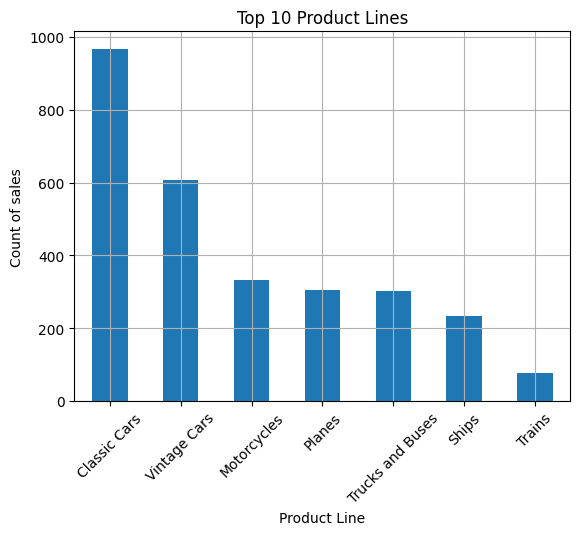

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("sales_data_sample.csv", encoding="latin1")

top_products = df["PRODUCTLINE"].value_counts().head(10)

top_products.plot(kind="bar")
plt.title("Top 10 Product Lines")
plt.ylabel("Count of sales")
plt.xlabel("Product Line")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

<Axes: xlabel='ORDERDATE'>

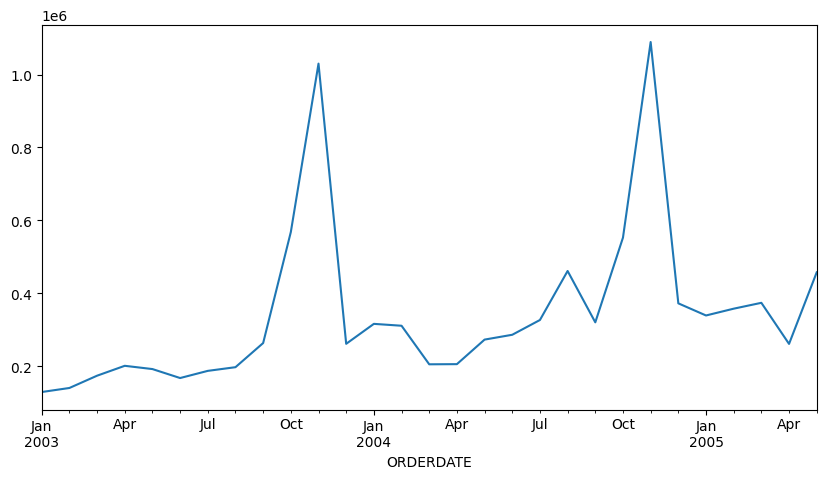

In [ ]:
df['ORDERDATE'] = pd.to_datetime(df['ORDERDATE'])

df.groupby(df['ORDERDATE'].dt.to_period('M'))['SALES'].sum().plot(kind='line', figsize=(10,5))

<Axes: xlabel='Customer Name'>

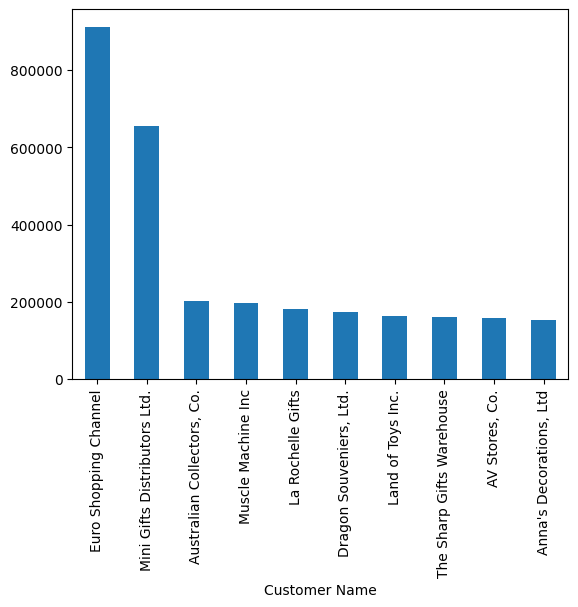

In [ ]:
df.groupby('CUSTOMERNAME')['SALES'].sum().sort_values(ascending=False).head(10).plot(kind='bar', xlabel='Customer Name')

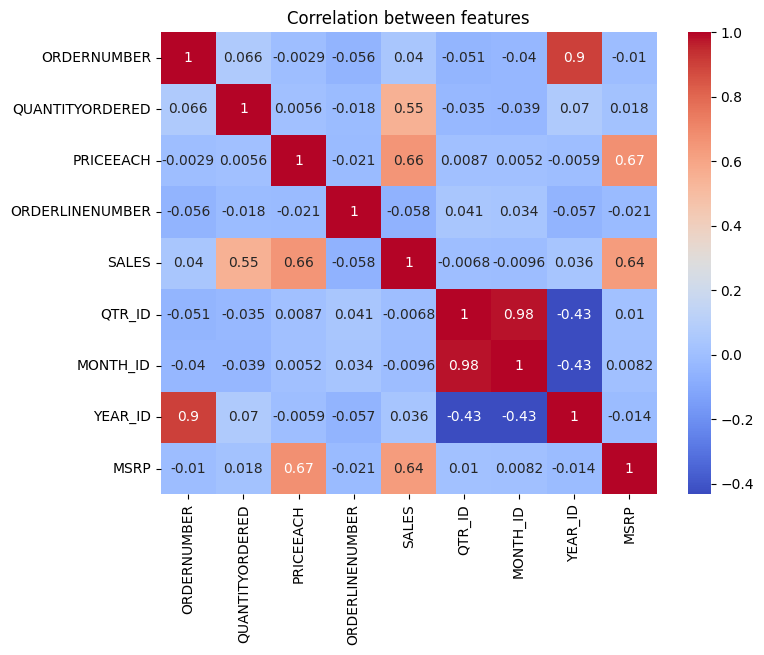

In [ ]:
import seaborn as sns

corr = df.corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation between features")
plt.show()

In [ ]:
#Dashboard in Plotly (inside Colab)

import plotly.express as px
import pandas as pd

df = pd.read_csv("sales_data_sample.csv", encoding="latin1")

df['ORDERDATE'] = pd.to_datetime(df['ORDERDATE'])

df.columns

df['YearMonth'] = df['ORDERDATE'].dt.to_period('M').astype(str)

monthly_sales = df.groupby('YearMonth')['SALES'].sum().reset_index()

fig = px.line(monthly_sales, x='YearMonth', y='SALES', title='Sales by Months')
fig.show()

In [ ]:
top_clients = df.groupby('CUSTOMERNAME')['SALES'].sum().sort_values(ascending=False).head(10).reset_index()
fig = px.bar(top_clients, x='CUSTOMERNAME', y='SALES', title='Top 10 Clients by Sales')
fig.show()

In [ ]:
fig = px.pie(df, names='PRODUCTLINE', values='SALES', title='Distribution of Sales by Product Lines')
fig.show()